In [3]:
from datasets import load_dataset

**Document Loading**

In [4]:
dataset = load_dataset("yelp_review_full")
texts = dataset["train"]["text"][:20000]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import re
import nltk
import spacy
!pip install gensim
import gensim
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**Text Cleaning**

In [7]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
  text = re.sub(r'<.*?>',"",text)
  text = re.sub(r"\s+"," ",text).strip()
  return text

cleaned_texts = [clean_text(t) for t in texts]



**Tokenization**

In [8]:
tokenized_texts = [word_tokenize(text) for text in cleaned_texts]


**Stopword removal**

In [9]:
filtered_tokens = [[word for word in text if word not in stop_words] for text in tokenized_texts]

**Lemmatization**

In [10]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()
lemmatized_texts = [" ".join([lemmatizer.lemmatize(word) for word in text]) for text in filtered_tokens]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Vocabulary Creation**

In [11]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(lemmatized_texts)
vocabulary = vectorizer.vocabulary_
print("Vocabulary size :", len(vocabulary))

Vocabulary size : 64028


**Bag of Words & TF-IDF**

In [12]:
bow_vectorizer = CountVectorizer(max_features=3000)
bow_vectors = bow_vectorizer.fit_transform(lemmatized_texts)


In [13]:
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
tfidf_vectors = tfidf_vectorizer.fit_transform(lemmatized_texts)

**Word Embeddings**

In [14]:
from gensim.models import Word2Vec

token_lists = [doc.split() for doc in lemmatized_texts]
word2vec_model = Word2Vec(sentences=token_lists, vector_size=100, window=5, min_count=2, workers=4)

**sentence embeddings**

In [15]:
import numpy as  np
def sentence_embeddings(sentence, word2vec_model):
  words = sentence.split()
  word_vectors = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
  if not word_vectors:
    return np.zeros(word2vec_model.vector_size)
  return np.mean(word_vectors, axis=0)


In [16]:
corpus_sentence_embeddings = np.array([sentence_embeddings(sentence, word2vec_model) for sentence in lemmatized_texts])


**Similarity Search**

In [17]:
query  = "The food is average and service is also good"
cleaned_query = clean_text(query)
tokenized_query = word_tokenize(cleaned_query)
query_vec = sentence_embeddings(cleaned_query, word2vec_model)
similarity_scores = cosine_similarity(query_vec.reshape(1, -1), corpus_sentence_embeddings)[0]

top_indices = similarity_scores.argsort()[-5:][::-1]
for idx in top_indices:
  print(similarity_scores[idx])
  print(texts[idx])


0.9540540458706268
Good for a cheap date. Food is okay, service is good!
0.9489809545765757
Good service. Not that high on the food.
0.9481470257792319
Overpriced, very slow service, food was decent.
0.9465198704559821
Great service and atmosphere.  The food is good - comfort food for the soul.
0.9402605364119472
Good Southwestern food: Addictive chips, efficient service.


**insights & visualization**

In [19]:
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_vectors.mean(axis=0).A1

top_words = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)[:15]

/tmp/ipykernel_9576/17027710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette="viridis")


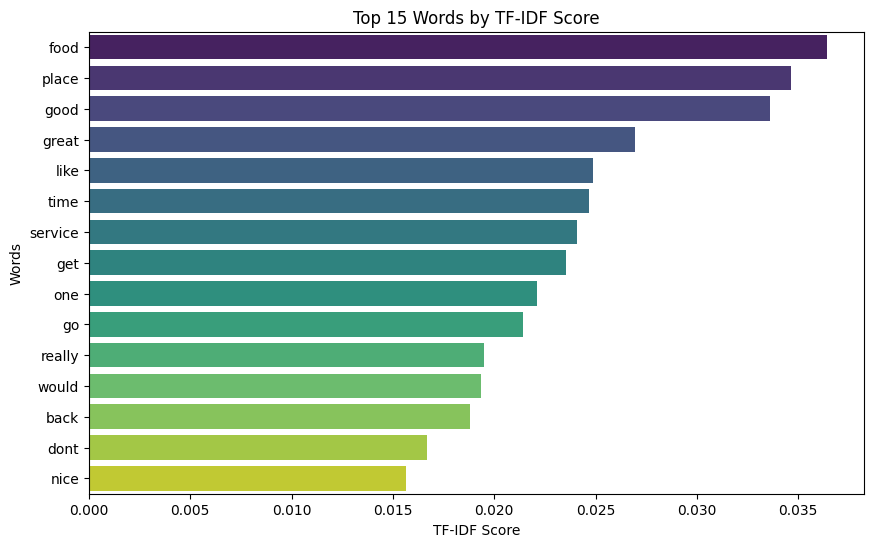

In [20]:
words, scores = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(scores), y=list(words), palette="viridis")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.title("Top 15 Words by TF-IDF Score")
plt.show()